# Лабораторная работа №5"Анализ последовательностей"

## Цель работы
Освоить методы поиска последовательных шаблонов (AprioriAll, PrefixSpan), реализовать базовые алгоритмы, применить их к реальным данным и сравнить эффективность.

### Задания:

1. Реализовать AprioriAll с нуля.

2. На реальных данных изучить влияние min_support, сравнить с ассоциативными правилами, добавить временные окна, визуализировать граф переходов.

3. Сравнить AprioriAll с библиотечным PrefixSpan.

4. Построить простую модель предсказания следующего товара.

5. Найти контрастные последовательности для клиентов с высоким и низким доходом.

### Реализация Apriori

In [24]:
import itertools
from collections import Counter
from typing import List, Set, Tuple, Dict

def apriori(transactions, min_support):
    n_trans = len(transactions)
    min_cnt = min_support * n_trans
    if min_cnt < 1:
        min_cnt = 1
    else:
        min_cnt = int(min_cnt)
    
    print(f"[Apriori] Порог частоты: {min_cnt}")
    
    single_counts = {}
    for basket in transactions:
        for product in basket:
            single_counts[product] = single_counts.get(product, 0) + 1
    
    frequent = {}
    L1 = []
    for product, cnt in single_counts.items():
        if cnt >= min_cnt:
            key = (product,)
            frequent[key] = cnt / n_trans
            L1.append(key)
    
    baskets_frozen = [frozenset(b) for b in transactions]
    
    k = 2
    prev = L1
    while prev:
        candidates = _gen_candidates(prev, k)
        if not candidates:
            break
        
        counter = {}
        for b in baskets_frozen:
            for cand in candidates:
                if cand.issubset(b):
                    counter[cand] = counter.get(cand, 0) + 1
        
        curr = []
        for cand, cnt in counter.items():
            if cnt >= min_cnt:
                key = tuple(sorted(cand))
                frequent[key] = cnt / n_trans
                curr.append(key)
        
        prev = curr
        k += 1
    
    return frequent

def _gen_candidates(prev, k):
    result = []
    n = len(prev)
    for i in range(n):
        a = set(prev[i])
        for j in range(i + 1, n):
            b = set(prev[j])
            if sorted(a)[:k-2] == sorted(b)[:k-2]:
                cand = a | b
                if len(cand) == k:
                    ok = True
                    for sub in itertools.combinations(cand, k-1):
                        if tuple(sorted(sub)) not in prev:
                            ok = False
                            break
                    if ok:
                        result.append(frozenset(cand))
    return result

def extract_rules(freq_itemsets, min_conf=0.5, min_lift=1.0, max_left_len=4, max_right_len=2):
    rules_data = []
    
    for itemset, supp_all in freq_itemsets.items():
        if len(itemset) < 2:
            continue
        
        items = set(itemset)
        size = len(itemset)
        
        for left_size in range(1, min(size, max_left_len + 1)):
            if left_size >= size:
                continue
            if max_right_len is not None and size - left_size > max_right_len:
                continue
                
            for left in itertools.combinations(itemset, left_size):
                left = tuple(sorted(left))
                right = tuple(sorted(items - set(left)))
                
                supp_left = freq_itemsets.get(left, 0.0)
                if supp_left == 0.0:
                    continue
                
                confidence = supp_all / supp_left
                if confidence < min_conf:
                    continue
                
                supp_right = freq_itemsets.get(right, 0.0)
                lift = confidence / supp_right if supp_right > 0 else float('inf')
                
                if lift < min_lift:
                    continue
                
                leverage = supp_all - supp_left * supp_right
                conviction = (1 - supp_right) / (1 - confidence) if confidence < 1 else float('inf')
                
                rules_data.append((left, right, supp_all, confidence, lift, conviction, leverage))
    
    return rules_data

def is_subsequence(sub, full):
    i = 0
    for itemset in full:
        if i < len(sub) and set(sub[i]).issubset(set(itemset)):
            i += 1
    return i == len(sub)

def filter_maximal(patterns_dict):
    items = list(patterns_dict.keys())
    items.sort(key=lambda x: -len(x))
    maximal = []
    for seq in items:
        if not any(is_subsequence(seq, longer) for longer in maximal):
            maximal.append(seq)
    return {seq: patterns_dict[seq] for seq in maximal}

code_to_desc = {}
desc_to_code = {}
for _, row in df[['StockCode', 'Description']].drop_duplicates().iterrows():
    if pd.notna(row['Description']):
        desc = row['Description'].strip()
        desc = ' '.join(desc.split()).upper()
        code_to_desc[row['StockCode']] = desc
        desc_to_code[desc] = row['StockCode']
    else:
        code_to_desc[row['StockCode']] = row['StockCode']
        desc_to_code[row['StockCode']] = row['StockCode']
test_keywords = ['TEST', 'SAMPLE', 'DAMAGES', 'ADJUSTMENT', 'BANK CHARGES', 'POSTAGE', 'CARRIAGE']
mask = ~df['Description'].str.upper().str.contains('|'.join(test_keywords), na=False)
df = df[mask]



**AprioriAll** — алгоритм поиска последовательных шаблонов, который находит частые последовательности покупок клиентов.

**Этапы алгоритма:**
1. **Сортировка** — группировка по клиенту и сортировка их транзакций по дате
2. **Поиск частых 1-последовательностей** — все товары, которые встречаются у ≥ min_support клиентов
3. **Генерация кандидатов** — из частых последовательностей длины k-1 создаём кандидаты длины k:
   - Слияние двух последовательностей с одинаковым префиксом
   - Добавление нового itemset в конец
4. **Отсев по Apriori-свойству** — если какая-то (k-1)-подпоследовательность кандидата не является частой, кандидат отбрасывается
5. **Подсчёт поддержки** — для каждого кандидата проверяем, скольким клиентам он принадлежит как подпоследовательность
6. **Повтор** — пока генерируются новые кандидаты

# Реализация AprioriAll
## Шаг 1. Сортировка по клиенту, дате, времени, номеру визита

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import time
from collections import defaultdict, Counter
from typing import List, Set, Tuple, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

try:
    from prefixspan import PrefixSpan
    PREFIXSPAN_AVAILABLE = True
except ImportError:
    print("Для сравнения установите: pip install prefixspan")
    PREFIXSPAN_AVAILABLE = False

df = pd.read_csv('online_retail_2.csv', sep=';', encoding='utf-8-sig')
print(f"Исходный размер: {len(df)}")

df['Price'] = df['Price'].astype(str).str.replace(',', '.').astype(float)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d.%m.%Y %H:%M', errors='coerce')
df = df[df['Quantity'] > 0]                     # только продажи
df = df.dropna(subset=['CustomerID'])           # удаляем строки без CustomerID
df['CustomerID'] = df['CustomerID'].astype(int)

print(f"После очистки: {len(df)}")
print(f"Уникальных клиентов: {df['CustomerID'].nunique()}")
print(f"Уникальных товаров : {df['StockCode'].nunique()}")

df_sorted = df.sort_values(['CustomerID', 'InvoiceDate'])

Исходный размер: 525461
После очистки: 407695
Уникальных клиентов: 4314
Уникальных товаров : 4017


## Шаг 2. Поиск частых наборов 

In [26]:
from mlxtend.frequent_patterns import apriori as mlxtend_apriori
from mlxtend.preprocessing import TransactionEncoder

def convert_to_desc(items_list):
    return [code_to_desc.get(code, code) for code in items_list]

all_transactions_desc = df.groupby('InvoiceNo')['StockCode'].apply(lambda x: convert_to_desc(list(set(x)))).tolist()

te = TransactionEncoder()
te_ary = te.fit(all_transactions_desc).transform(all_transactions_desc)
df_apriori = pd.DataFrame(te_ary, columns=te.columns_)

## Шаг 3. Преобразование в последовательности клиентов (клиентские последовательности)

In [27]:
transactions = df_sorted.groupby(['CustomerID', 'InvoiceNo', 'InvoiceDate'])['StockCode'].apply(lambda x: set(x.unique())).reset_index()
transactions.rename(columns={'StockCode': 'itemset_code'}, inplace=True)
transactions['itemset'] = transactions['itemset_code'].apply(lambda s: {code_to_desc.get(code, code) for code in s})

def is_valid_item(desc):
    if not desc or len(desc) < 3:
        return False
    if 'TEST' in desc.upper() or 'SAMPLE' in desc.upper():
        return False
    return True

client_sequences = []
for cust, group in transactions.sort_values('InvoiceDate').groupby('CustomerID'):
    seq = []
    for itemset in group['itemset'].tolist():
        filtered_itemset = {item for item in itemset if is_valid_item(item)}
        if filtered_itemset: 
            seq.append(filtered_itemset)
    if len(seq) >= 2: 
        client_sequences.append(seq)

print(f"Клиентов с >=2 валидными транзакциями: {len(client_sequences)}")

if client_sequences:
    example_seq = client_sequences[0]
    print("\nПример первой последовательности (первые 3 itemset):")
    for i, itemset in enumerate(example_seq[:3]):
        items_list = list(itemset)
        if len(items_list) > 3:
            print(f"  {i+1}. {', '.join(items_list[:3])} ... ({len(items_list)} товаров)")
        else:
            print(f"  {i+1}. {', '.join(items_list)}")

Клиентов с >=2 валидными транзакциями: 2896

Пример первой последовательности (первые 3 itemset):
  1. RED RETROSPOT CHILDRENS UMBRELLA, EDWARDIAN PARASOL NATURAL, EDWARDIAN PARASOL RED ... (5 товаров)
  2. DOORMAT WELCOME TO OUR HOME, DOORMAT CHRISTMAS VILLAGE, DOORMAT FANCY FONT HOME SWEET HOME ... (19 товаров)


## Шаг 4. Поиск частых последовательностей (алгоритм AprioriAll)

In [28]:
def is_subsequence(subseq, fullseq):
    it = iter(fullseq)
    for itemset in subseq:
        found = False
        for cand in it:
            if itemset.issubset(cand):
                found = True
                break
        if not found:
            return False
    return True

def apriori_all(sequences: List[List[Set]], min_support: float) -> Dict[Tuple, float]:

    n_clients = len(sequences)
    min_count = max(1, int(min_support * n_clients))
    print(f"[AprioriAll] Клиентов: {n_clients}, min_sup={min_support} -> min_count={min_count}")
    
    item_counts = Counter()
    for seq in sequences:
        unique_items = set()
        for itemset in seq:
            unique_items.update(itemset)
        for item in unique_items:
            item_counts[item] += 1
    
    freq1 = {(frozenset([item]),): cnt/n_clients for item, cnt in item_counts.items() if cnt >= min_count}
    all_freq = dict(freq1)
    prev_freq = list(freq1.keys())   
    
    k = 2
    while prev_freq:
        candidates = set()
        for i in range(len(prev_freq)):
            for j in range(i+1, len(prev_freq)):
                seq_i = prev_freq[i]
                seq_j = prev_freq[j]
                if seq_i[:-1] == seq_j[:-1]:
                    new_seq = seq_i + (seq_j[-1],)
                    candidates.add(new_seq)
        for seq in prev_freq:
            for itemset, _ in freq1.items():   
                new_seq = seq + itemset
                candidates.add(new_seq)
        
        valid_candidates = []
        for cand in candidates:
            ok = True
            for i in range(len(cand)):
                sub = cand[:i] + cand[i+1:]
                if sub not in all_freq:
                    ok = False
                    break
            if ok:
                valid_candidates.append(cand)
        
        if not valid_candidates:
            break
        
        counts = defaultdict(int)
        for seq in sequences:
            for cand in valid_candidates:
                if is_subsequence(cand, seq):
                    counts[cand] += 1
        
        curr_freq = []
        for cand, cnt in counts.items():
            if cnt >= min_count:
                sup = cnt / n_clients
                all_freq[cand] = sup
                curr_freq.append(cand)
        
        prev_freq = curr_freq
        k += 1
        print(f"  Длина {k-1}: найдено {len(curr_freq)} частых последовательностей")
    
    return all_freq

### Проверка на синтетическом примере

In [29]:
synth_seqs = [
    [frozenset([1,5]), frozenset([2]), frozenset([3]), frozenset([4])],
    [frozenset([1]), frozenset([3]), frozenset([4]), frozenset([3,5])],
    [frozenset([1]), frozenset([2]), frozenset([3]), frozenset([4])],
    [frozenset([1]), frozenset([3]), frozenset([5]), frozenset([4])],
    [frozenset([4]), frozenset([5])]
]
freq_synth = apriori_all(synth_seqs, 0.4)
print("\nНайденные частые последовательности (длина >=1):")
for seq, sup in sorted(freq_synth.items(), key=lambda x: (-len(x[0]), -x[1])):
    if len(seq) == 1:
        print(f"<{set(seq[0])}> : {sup:.2f}")
    else:
        s = " -> ".join([str(set(it)) for it in seq])
        print(f"<{s}> : {sup:.2f}")

[AprioriAll] Клиентов: 5, min_sup=0.4 -> min_count=2
  Длина 2: найдено 10 частых последовательностей
  Длина 3: найдено 5 частых последовательностей
  Длина 4: найдено 1 частых последовательностей

Найденные частые последовательности (длина >=1):
<{1} -> {2} -> {3} -> {4}> : 0.40
<{1} -> {3} -> {4}> : 0.80
<{1} -> {2} -> {4}> : 0.40
<{2} -> {3} -> {4}> : 0.40
<{1} -> {2} -> {3}> : 0.40
<{1} -> {3} -> {5}> : 0.40
<{3} -> {4}> : 0.80
<{1} -> {3}> : 0.80
<{1} -> {4}> : 0.80
<{2} -> {4}> : 0.40
<{5} -> {4}> : 0.40
<{1} -> {2}> : 0.40
<{2} -> {3}> : 0.40
<{3} -> {5}> : 0.40
<{4} -> {5}> : 0.40
<{1} -> {5}> : 0.40
<{4}> : 1.00
<{1}> : 0.80
<{3}> : 0.80
<{5}> : 0.80
<{2}> : 0.40


### Запуск на реальных данных при разных min_sup

[AprioriAll] Клиентов: 2897, min_sup=0.05 -> min_count=144
  Длина 2: найдено 235 частых последовательностей
  Длина 3: найдено 13 частых последовательностей
  Длина 4: найдено 1 частых последовательностей
  Длина 5: найдено 1 частых последовательностей
  Длина 6: найдено 0 частых последовательностей
min_sup=0.05 -> 755 паттернов, время 529.32 с
[AprioriAll] Клиентов: 2897, min_sup=0.1 -> min_count=289
  Длина 2: найдено 4 частых последовательностей
  Длина 3: найдено 1 частых последовательностей
  Длина 4: найдено 0 частых последовательностей
min_sup=0.10 -> 104 паттернов, время 18.33 с
[AprioriAll] Клиентов: 2897, min_sup=0.2 -> min_count=579
  Длина 2: найдено 1 частых последовательностей
  Длина 3: найдено 0 частых последовательностей
min_sup=0.20 -> 5 паттернов, время 0.13 с


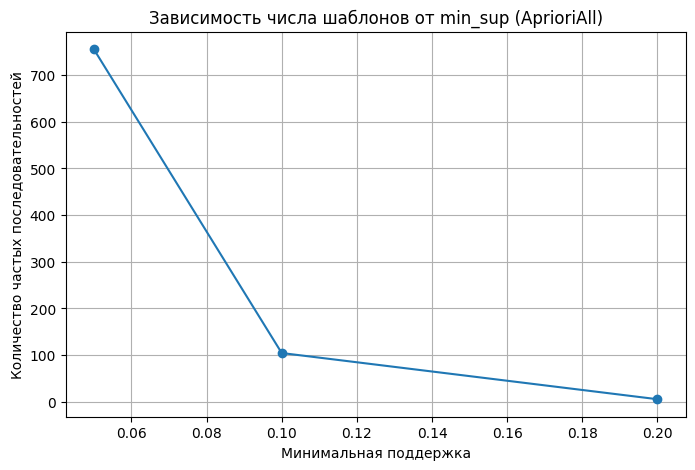

In [7]:
min_supports = [0.05, 0.10, 0.20]
counts = []
times = []
for ms in min_supports:
    start = time.time()
    freq = apriori_all(client_sequences, ms)
    elapsed = time.time() - start
    counts.append(len(freq))
    times.append(elapsed)
    print(f"min_sup={ms:.2f} -> {len(freq)} паттернов, время {elapsed:.2f} с")

plt.figure(figsize=(8,5))
plt.plot(min_supports, counts, marker='o', linestyle='-')
plt.xlabel('Минимальная поддержка')
plt.ylabel('Количество частых последовательностей')
plt.title('Зависимость числа шаблонов от min_sup (AprioriAll)')
plt.grid(True)
plt.show()

С ростом min_support количество частых последовательностей должно **резко уменьшаться**, так как:
- При 5% поддержке (≈ 145 клиентов из 2897) алгоритм найдёт много паттернов
- При 10% (≈ 290 клиентов) — значительно меньше
- При 20% (≈ 579 клиентов) — останутся только самые популярные товары и короткие последовательности

### Вывод о масштабируемости

AprioriAll имеет **экспоненциальную сложность** по длине последовательностей:
- Каждая итерация требует генерации кандидатов и сканирования всех клиентских последовательностей
- При низкой поддержке количество частых последовательностей резко возрастает, что приводит к большому колличеству комбинаций
- На реальных данных (4000+ товаров) алгоритм становится **неприменим** при `min_support < 1%`

## Шаг 5. Поиск максимальных последовательностей

In [32]:
def maximal_sequences(freq_dict):
    items = list(freq_dict.keys())
    is_maximal = [True] * len(items)
    for i, seq_i in enumerate(items):
        if not is_maximal[i]:
            continue
        for j, seq_j in enumerate(items):
            if i == j:
                continue
            if is_subsequence(seq_i, seq_j):
                is_maximal[i] = False
                break
    return [items[i] for i, val in enumerate(is_maximal) if val]

freq_real = apriori_all(client_sequences, 0.05)   
max_seqs = maximal_sequences(freq_real)
print(f"Всего частых последовательностей (min_sup=0.05): {len(freq_real)}")
print(f"Из них максимальных: {len(max_seqs)}")
print("\nПримеры максимальных последовательностей (первые 5):")
for seq in max_seqs[:5]:
    s = " -> ".join(["("+",".join(sorted(it))+")" for it in seq])
    print(f"  {s} (sup={freq_real[seq]:.3f})")

[AprioriAll] Клиентов: 2896, min_sup=0.05 -> min_count=144
  Длина 2: найдено 236 частых последовательностей
  Длина 3: найдено 13 частых последовательностей
  Длина 4: найдено 1 частых последовательностей
  Длина 5: найдено 1 частых последовательностей
  Длина 6: найдено 0 частых последовательностей
Всего частых последовательностей (min_sup=0.05): 757
Из них максимальных: 677

Примеры максимальных последовательностей (первые 5):
  (DOORMAT FANCY FONT HOME SWEET HOME) (sup=0.073)
  (EDWARDIAN PARASOL RED) (sup=0.059)
  (DOORMAT 3 SMILEY CATS) (sup=0.056)
  (EDWARDIAN PARASOL BLACK) (sup=0.076)
  (DOORMAT WELCOME PUPPIES) (sup=0.065)


## Шаг 6. Итоговый поиск частых последовательностей

In [39]:
sorted_freq = sorted(freq_real.items(), key=lambda x: (-len(x[0]), -x[1]))
print("Топ-10 самых длинных частых последовательностей (min_sup=0.05):")
for i, (seq, sup) in enumerate(sorted_freq[:10], 1):
    seq_str = " -> ".join(["(" + ", ".join(list(it)[:3]) + ("..." if len(it) > 3 else "") + ")" for it in seq])
    print(f"{i}. {seq_str} (support={sup:.3f})")
    
non_trivial_seqs = [(seq, sup) for seq, sup in freq_real.items() if len(set(seq)) > 1]
sorted_freq = sorted(non_trivial_seqs, key=lambda x: (-len(x[0]), -x[1]))

print("\n\nТоп-10 самых длинных нетривиальных частых последовательностей (min_sup=0.05):")
for i, (seq, sup) in enumerate(sorted_freq[:10], 1):
    seq_str = " -> ".join(["(" + ", ".join(list(it)[:3]) + ("..." if len(it) > 3 else "") + ")" for it in seq])
    print(f"{i}. {seq_str} (support={sup:.3f}, длина={len(seq)})")

Топ-10 самых длинных частых последовательностей (min_sup=0.05):
1. (WHITE HANGING HEART T-LIGHT HOLDER) -> (WHITE HANGING HEART T-LIGHT HOLDER) -> (WHITE HANGING HEART T-LIGHT HOLDER) -> (WHITE HANGING HEART T-LIGHT HOLDER) -> (WHITE HANGING HEART T-LIGHT HOLDER) (support=0.052)
2. (WHITE HANGING HEART T-LIGHT HOLDER) -> (WHITE HANGING HEART T-LIGHT HOLDER) -> (WHITE HANGING HEART T-LIGHT HOLDER) -> (WHITE HANGING HEART T-LIGHT HOLDER) (support=0.082)
3. (WHITE HANGING HEART T-LIGHT HOLDER) -> (WHITE HANGING HEART T-LIGHT HOLDER) -> (WHITE HANGING HEART T-LIGHT HOLDER) (support=0.130)
4. (JUMBO BAG RED RETROSPOT) -> (JUMBO BAG RED RETROSPOT) -> (JUMBO BAG RED RETROSPOT) (support=0.071)
5. (WHITE HANGING HEART T-LIGHT HOLDER) -> (WHITE HANGING HEART T-LIGHT HOLDER) -> (RED HANGING HEART T-LIGHT HOLDER) (support=0.070)
6. (WHITE HANGING HEART T-LIGHT HOLDER) -> (RED HANGING HEART T-LIGHT HOLDER) -> (WHITE HANGING HEART T-LIGHT HOLDER) (support=0.060)
7. (REGENCY CAKESTAND 3 TIER) -> (REG

### 1. Сравнение с ассоциативными правилами

In [35]:
all_transactions_apriori = df.groupby('InvoiceNo')['StockCode'].apply(lambda x: list(set(x))).tolist()
print(f"Всего транзакций для Apriori: {len(all_transactions_apriori)}")

min_sup_apriori = 0.005   
freq_itemsets_apriori = apriori(all_transactions_apriori, min_sup_apriori)
print(f"Найдено частых наборов: {len(freq_itemsets_apriori)}")

if len(freq_itemsets_apriori) == 0:
    print("Нет частых наборов при min_sup =", min_sup_apriori)
    print("Попробуйте уменьшить min_sup, например, до 0.001")
else:
    rules_apriori = extract_rules(freq_itemsets_apriori, min_conf=0.3, min_lift=1.0)
    rules_apriori.sort(key=lambda x: x[4], reverse=True) 
    top3 = rules_apriori[:3]
    
    print("\nТоп-3 ассоциативных правила по lift (ваш Apriori):")
    for i, (left, right, supp, conf, lift, conv, lev) in enumerate(top3, 1):
        lhs = ', '.join(list(left))
        rhs = ', '.join(list(right))
        print(f"{i}. {lhs} -> {rhs} | lift={lift:.2f}, support={supp:.3f}, confidence={conf:.2f}")
    
    print("\nПроверка на принадлежность к частым последовательностям (min_sup=0.05 для AprioriAll):")
    freq_seq_check = freq_real   
    for i, (left, right, _, _, _, _, _) in enumerate(top3, 1):
        lhs_set = frozenset(left)  
        rhs_set = frozenset(right)
        seq = (lhs_set, rhs_set)     
        if seq in freq_seq_check:
            print(f"Правило {i}: последовательность {seq} частая (sup={freq_seq_check[seq]:.3f})")
        else:
            print(f"Правило {i}: последовательность {seq} НЕ является частой")

Всего транзакций для Apriori: 19215
[Apriori] Порог частоты: 96
Найдено частых наборов: 3586

Топ-3 ассоциативных правила по lift (ваш Apriori):
1. 22520, 22525 -> 22521, 22524 | lift=150.71, support=0.006, confidence=0.93
2. 22521, 22524 -> 22520, 22525 | lift=150.71, support=0.006, confidence=0.94
3. 22521, 22525 -> 22523, 22524 | lift=132.98, support=0.005, confidence=0.71

Проверка на принадлежность к частым последовательностям (min_sup=0.05 для AprioriAll):
Правило 1: последовательность (frozenset({'22520', '22525'}), frozenset({'22521', '22524'})) НЕ является частой
Правило 2: последовательность (frozenset({'22521', '22524'}), frozenset({'22520', '22525'})) НЕ является частой
Правило 3: последовательность (frozenset({'22521', '22525'}), frozenset({'22524', '22523'})) НЕ является частой


### 2. Временные окна (max_gap)

In [11]:
def split_by_gap(transactions_df, max_gap_days=7):
    df_sorted = transactions_df.sort_values(['CustomerID', 'InvoiceDate'])
    sessions = []
    current_cust = None
    current_seq = []
    prev_date = None
    for _, row in df_sorted.iterrows():
        cust = row['CustomerID']
        date = row['InvoiceDate']
        items = row['itemset']
        if cust != current_cust:
            if current_seq:
                sessions.append(current_seq)
            current_cust = cust
            current_seq = [items]
            prev_date = date
        else:
            if (date - prev_date).days > max_gap_days:
                if len(current_seq) >= 2:
                    sessions.append(current_seq)
                current_seq = [items]
            else:
                current_seq.append(items)
            prev_date = date
    if current_seq:
        sessions.append(current_seq)
    return [seq for seq in sessions if len(seq) >= 2]

sessions_gap7 = split_by_gap(transactions, max_gap_days=7)
print(f"Количество сессий (последовательностей) при gap=7: {len(sessions_gap7)}")

freq_gap7 = apriori_all(sessions_gap7, 0.05)
print(f"Частых последовательностей при gap=7: {len(freq_gap7)}")
print(f"Частых последовательностей без gap (∞): {len(freq_real)}")

only_inf = set(freq_real.keys()) - set(freq_gap7.keys())
if only_inf:
    example = next(iter(only_inf))
    print("\nПример последовательности, присутствовавшей при ∞, но пропавшей при gap=7:")
    s_ex = " -> ".join(["("+",".join(sorted(it))+")" for it in example])
    print(f"  {s_ex} (support ∞ = {freq_real[example]:.3f})")

Количество сессий (последовательностей) при gap=7: 2386
[AprioriAll] Клиентов: 2386, min_sup=0.05 -> min_count=119
  Длина 2: найдено 1 частых последовательностей
  Длина 3: найдено 0 частых последовательностей
Частых последовательностей при gap=7: 132
Частых последовательностей без gap (∞): 755

Пример последовательности, присутствовавшей при ∞, но пропавшей при gap=7:
  (84836) -> (85123A) (support ∞ = 0.064)


### 3. Визуализация графа переходов для одного частого шаблона

Топ-6 самых длинных частых последовательностей:
1. (WHITE HANGING HEART T-LIGHT HOLDER) → (WHITE HANGING HEART T-LIGHT HOLDER) → (RED HANGING HEART T-LIGHT HOLDER) (support=0.070, длина=3)
2. (WHITE HANGING HEART T-LIGHT HOLDER) → (RED HANGING HEART T-LIGHT HOLDER) → (WHITE HANGING HEART T-LIGHT HOLDER) (support=0.060, длина=3)
3. (RED HANGING HEART T-LIGHT HOLDER) → (WHITE HANGING HEART T-LIGHT HOLDER) → (WHITE HANGING HEART T-LIGHT HOLDER) (support=0.055, длина=3)
4. (WHITE HANGING HEART T-LIGHT HOLDER) → (WHITE HANGING HEART T-LIGHT HOLDER) → (HEART OF WICKER LARGE) (support=0.054, длина=3)
5. (WHITE HANGING HEART T-LIGHT HOLDER) → (WHITE HANGING HEART T-LIGHT HOLDER) → (HEART OF WICKER SMALL) (support=0.050, длина=3)
6. (WHITE HANGING HEART T-LIGHT HOLDER) → (RED HANGING HEART T-LIGHT HOLDER) (support=0.098, длина=2)


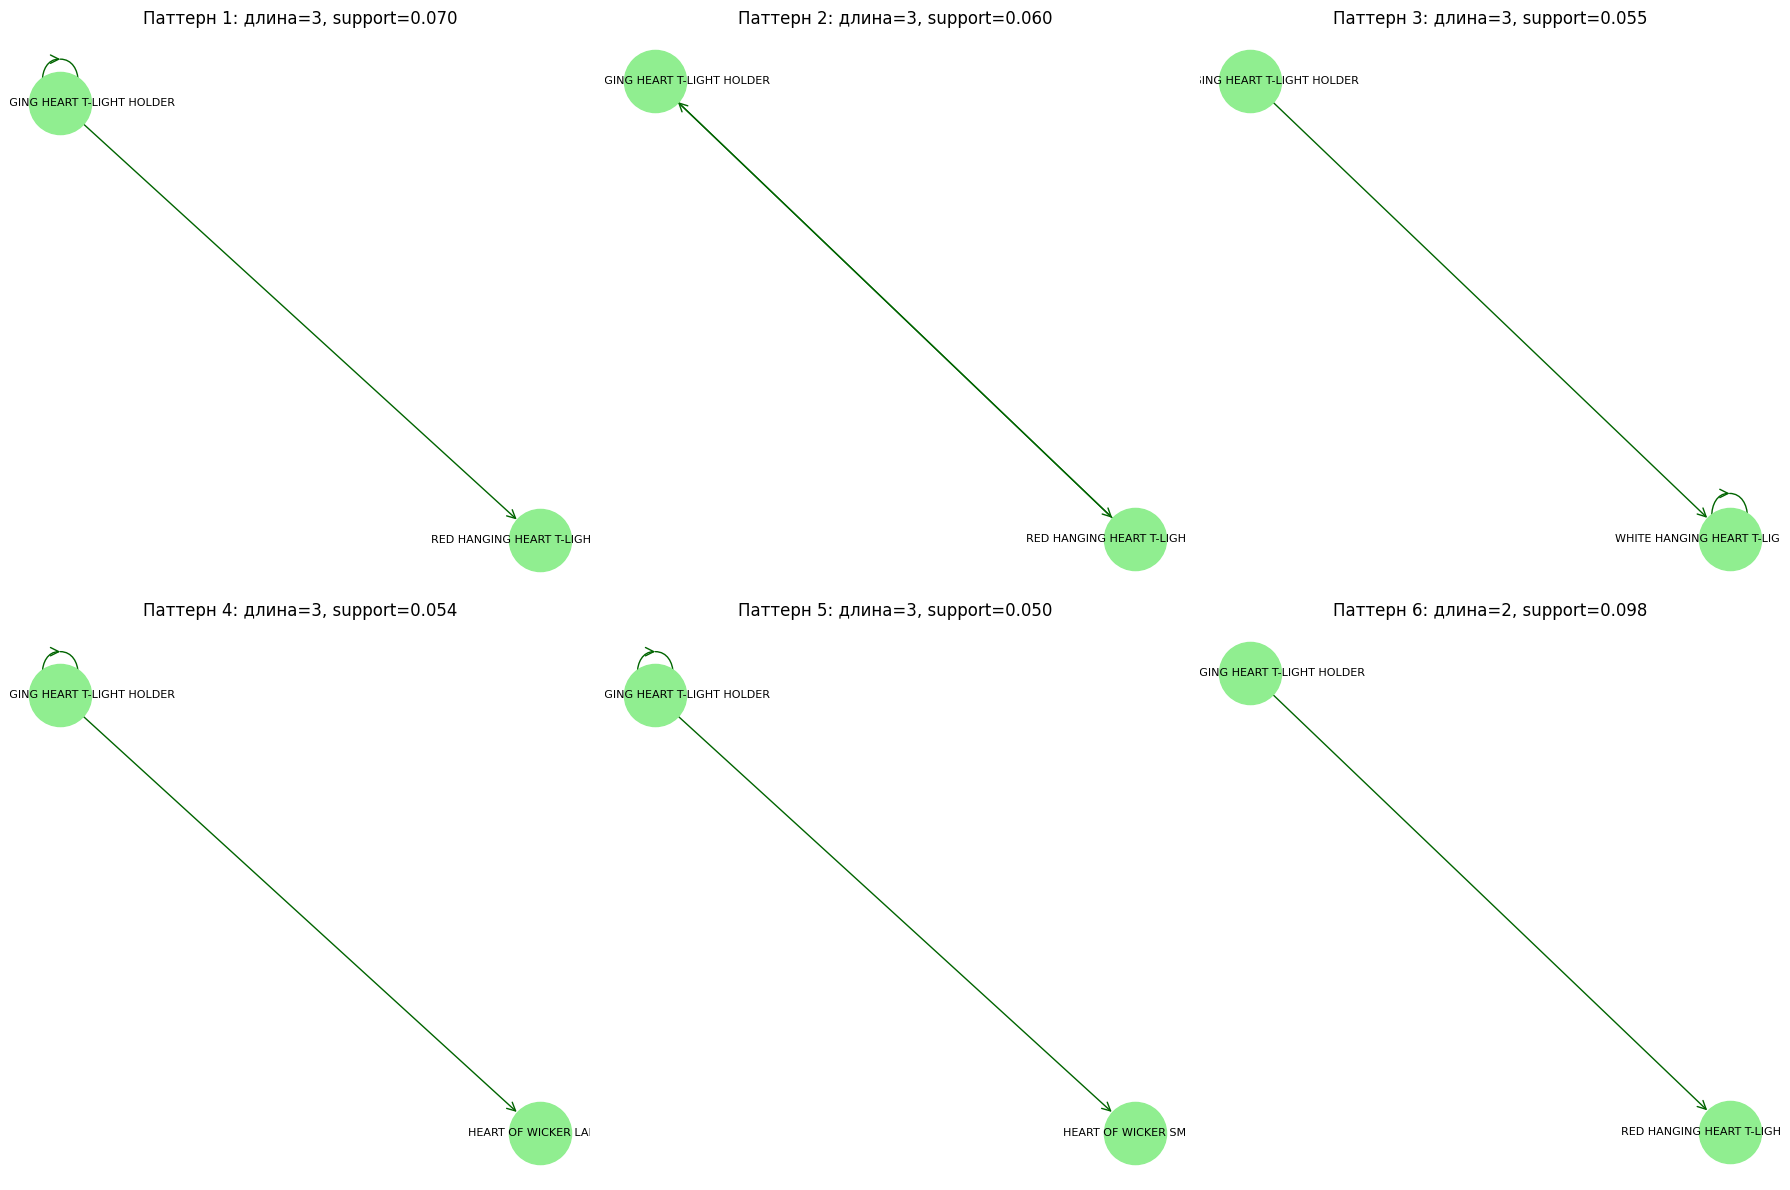

In [34]:
import networkx as nx

non_trivial = [(seq, sup) for seq, sup in freq_real.items() if len(seq) >= 2 and len(set(seq)) > 1]
non_trivial.sort(key=lambda x: (-len(x[0]), -x[1]))

top6 = non_trivial[:6]  

print(f"Топ-6 самых длинных частых последовательностей:")
for i, (seq, sup) in enumerate(top6, 1):
    seq_str = " → ".join(["(" + ", ".join(list(it)[:2]) + ("..." if len(it) > 2 else "") + ")" for it in seq])
    print(f"{i}. {seq_str} (support={sup:.3f}, длина={len(seq)})")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (seq, sup) in enumerate(top6):
    G = nx.DiGraph()
    for i in range(len(seq) - 1):
        src = ", ".join(list(seq[i])[:2]) + ("..." if len(seq[i]) > 2 else "")
        dst = ", ".join(list(seq[i + 1])[:2]) + ("..." if len(seq[i + 1]) > 2 else "")
        G.add_edge(src, dst)
    
    if G.number_of_nodes() == 0:
        axes[idx].text(0.5, 0.5, f"Последовательность\n{seq_str[:30]}...\n(пустой граф)", 
                      ha='center', va='center', fontsize=10)
        axes[idx].set_title(f"Паттерн {idx+1} (support={sup:.3f})")
        axes[idx].axis('off')
        continue
    
    pos = nx.spring_layout(G, seed=42, k=2)
    nx.draw(G, pos, ax=axes[idx], with_labels=True, node_color='lightgreen', 
            edge_color='darkgreen', node_size=2000, font_size=8, arrows=True,
            arrowsize=15, arrowstyle='->')
    axes[idx].set_title(f"Паттерн {idx+1}: длина={len(seq)}, support={sup:.3f}")

plt.tight_layout()
plt.show()

### 4. Сравнение с библиотекой PrefixSpan

In [46]:
synth_sequences = [
    [frozenset([1,5]), frozenset([2]), frozenset([3]), frozenset([4])],
    [frozenset([1]), frozenset([3]), frozenset([4]), frozenset([3,5])],
    [frozenset([1]), frozenset([2]), frozenset([3]), frozenset([4])],
    [frozenset([1]), frozenset([3]), frozenset([5]), frozenset([4])],
    [frozenset([4]), frozenset([5])]
]

print("\nСинтетические данные (5 клиентов):")
for i, seq in enumerate(synth_sequences, 1):
    seq_str = " -> ".join([str(set(it)) for it in seq])
    print(f"  Клиент {i}: {seq_str}")

min_support = 0.4
print(f"\nmin_support = {min_support} (абсолютный порог = 2 клиента)")

start_aa = time.time()
freq_aa_synth = apriori_all(synth_sequences, min_support)
elapsed_aa = time.time() - start_aa

len_counts_aa = defaultdict(int)
for seq in freq_aa_synth.keys():
    len_counts_aa[len(seq)] += 1

print(f"\nРезультаты AprioriAll:")
print(f"  Время выполнения: {elapsed_aa:.5f} сек")
print(f"  Всего частых последовательностей: {len(freq_aa_synth)}")
print(f"  По длинам: {dict(len_counts_aa)}")

print(f"\n  Найденные частые последовательности:")
for seq, sup in sorted(freq_aa_synth.items(), key=lambda x: (-len(x[0]), -x[1])):
    if len(seq) == 1:
        print(f"    <{set(seq[0])}> : support={sup:.2f}")
    else:
        seq_str = " -> ".join([str(set(it)) for it in seq])
        print(f"    <{seq_str}> : support={sup:.2f}")

if PREFIXSPAN_AVAILABLE:
    print("\n" + "-" * 40)
    print("ЗАПУСК PREFIXSPAN (библиотечная реализация)")
    print("-" * 40)
    
    synth_sequences_ps = []
    for seq in synth_sequences:
        ps_seq = []
        for itemset in seq:
            items_tuple = tuple(sorted(itemset))
            if len(items_tuple) == 1:
                ps_seq.append(str(items_tuple[0]))  
            else:
                ps_seq.append("-".join(map(str, items_tuple))) 
        synth_sequences_ps.append(ps_seq)
    
    print(f"  Данные для PrefixSpan ({len(synth_sequences_ps)} последовательностей):")
    for i, seq in enumerate(synth_sequences_ps, 1):
        print(f"    Клиент {i}: {' -> '.join(seq)}")
    
    minsup_count = 1
    print(f"  minsup (абсолютный) = {minsup_count}")
    
    start_ps = time.time()
    ps = PrefixSpan(synth_sequences_ps)
    result_ps = ps.frequent(minsup=minsup_count)
    elapsed_ps = time.time() - start_ps
    
    patterns_ps = []
    for item in result_ps:
        if isinstance(item, tuple) and len(item) == 2:
            if isinstance(item[0], (int, float)):
                support = item[0]
                pattern = item[1] if isinstance(item[1], list) else item[1]
                patterns_ps.append((pattern, support))
            else:
                support = item[1] if isinstance(item[1], (int, float)) else None
                pattern = item[0] if isinstance(item[0], list) else item[0]
                patterns_ps.append((pattern, support))
        else:
            patterns_ps.append((item, None))
    
    len_counts_ps = defaultdict(int)
    valid_patterns = []
    for pattern, support in patterns_ps:
        if isinstance(pattern, (list, tuple)):
            len_counts_ps[len(pattern)] += 1
            valid_patterns.append((pattern, support))
    
    print(f"\nРезультаты PrefixSpan:")
    print(f"  Время выполнения: {elapsed_ps:.6f} сек")
    print(f"  Всего частых последовательностей: {len(valid_patterns)}")
    print(f"  По длинам: {dict(len_counts_ps)}")
    
    print(f"\n  Найденные частые последовательности:")
    for pattern, sup in sorted(valid_patterns, key=lambda x: (-len(x[0]), -x[1] if x[1] else 0))[:20]:
        if sup is not None:
            seq_str = " -> ".join(pattern)
            print(f"    <{seq_str}> : support={sup}")
        else:
            print(f"    {pattern}")
    
    print(f"{'Алгоритм':<25} {'Время (сек)':<14} {'Кол-во шаблонов':<18} ")
    print("-" * 70)
    print(f"{'AprioriAll (наша)':<25} {elapsed_aa:<14.6f} {len(freq_aa_synth):<18}")
    print(f"{'PrefixSpan (библ.)':<25} {elapsed_ps:<14.6f} {len(valid_patterns):<18}")


Синтетические данные (5 клиентов):
  Клиент 1: {1, 5} -> {2} -> {3} -> {4}
  Клиент 2: {1} -> {3} -> {4} -> {3, 5}
  Клиент 3: {1} -> {2} -> {3} -> {4}
  Клиент 4: {1} -> {3} -> {5} -> {4}
  Клиент 5: {4} -> {5}

min_support = 0.4 (абсолютный порог = 2 клиента)
[AprioriAll] Клиентов: 5, min_sup=0.4 -> min_count=2
  Длина 2: найдено 10 частых последовательностей
  Длина 3: найдено 5 частых последовательностей
  Длина 4: найдено 1 частых последовательностей

Результаты AprioriAll:
  Время выполнения: 0.00037 сек
  Всего частых последовательностей: 21
  По длинам: {1: 5, 2: 10, 3: 5, 4: 1}

  Найденные частые последовательности:
    <{1} -> {2} -> {3} -> {4}> : support=0.40
    <{1} -> {3} -> {4}> : support=0.80
    <{1} -> {2} -> {4}> : support=0.40
    <{2} -> {3} -> {4}> : support=0.40
    <{1} -> {2} -> {3}> : support=0.40
    <{1} -> {3} -> {5}> : support=0.40
    <{3} -> {4}> : support=0.80
    <{1} -> {3}> : support=0.80
    <{1} -> {4}> : support=0.80
    <{2} -> {4}> : support=0

### 5. Предсказание следующего события (контекстные последовательности)

In [40]:
from sklearn.model_selection import train_test_split

train_seqs = []
test_pairs = []   
for cust, group in transactions.sort_values('InvoiceDate').groupby('CustomerID'):
    seq = group['itemset'].tolist()
    if len(seq) < 2:
        continue
    split = max(1, int(0.8 * len(seq)))
    train_part = seq[:split]
    test_part = seq[split:]
    if len(test_part) >= 1:
        test_pairs.append((train_part[-1], test_part[0]))
        train_seqs.append(train_part)

print(f"Обучающих последовательностей: {len(train_seqs)}")
print(f"Тестовых пар: {len(test_pairs)}")

freq_train = apriori_all(train_seqs, min_support=0.05)

def predict_next(itemset, freq_dict):
    best_y = None
    best_sup = -1
    for seq, sup in freq_dict.items():
        if len(seq) == 2 and seq[0] == itemset:
            if sup > best_sup:
                best_sup = sup
                best_y = seq[1]
    return best_y

all_item_counts = Counter()
for seq in train_seqs:
    for itemset in seq:
        for item in itemset:
            all_item_counts[item] += 1
global_top_item = all_item_counts.most_common(1)[0][0]
print(f"Самый частый товар (глобально): {global_top_item}")

correct_seq = 0
correct_baseline = 0
for last_itemset, real_itemset in test_pairs:
    pred_y = predict_next(last_itemset, freq_train)
    if pred_y is not None:
        if any(item in real_itemset for item in pred_y):
            correct_seq += 1
    if global_top_item in real_itemset:
        correct_baseline += 1

acc_seq = correct_seq / len(test_pairs) if test_pairs else 0
acc_baseline = correct_baseline / len(test_pairs) if test_pairs else 0
print(f"\nТочность предсказания")
print(f"  На основе последовательностей: {acc_seq:.3f}")
print(f"  Базовый (глобальный топ-товар): {acc_baseline:.3f}")

if acc_seq > acc_baseline:
    print("Учёт последовательности улучшает предсказание.")
else:
    print("В данном случае глобальный топ-товар оказался эффективнее.")

Обучающих последовательностей: 2897
Тестовых пар: 2897
[AprioriAll] Клиентов: 2897, min_sup=0.05 -> min_count=144
  Длина 2: найдено 67 частых последовательностей
  Длина 3: найдено 1 частых последовательностей
  Длина 4: найдено 1 частых последовательностей
  Длина 5: найдено 0 частых последовательностей
Самый частый товар (глобально): WHITE HANGING HEART T-LIGHT HOLDER

Точность предсказания
  На основе последовательностей: 0.003
  Базовый (глобальный топ-товар): 0.136
В данном случае глобальный топ-товар оказался эффективнее.


### 6. Контрастные последовательности: HighValue vs LowValue

Разделим клиентов по выручке (75-й перцентиль) и найдём последовательности, характерные для высокодоходных.

HighValue клиентов: 1079 (выручка ≥ 1722.80)
LowValue клиентов: 3235
HighValue последовательностей: 1058
LowValue последовательностей: 1839
[AprioriAll] Клиентов: 1058, min_sup=0.05 -> min_count=52
  Длина 2: найдено 5837 частых последовательностей
  Длина 3: найдено 4200 частых последовательностей
  Длина 4: найдено 1303 частых последовательностей
  Длина 5: найдено 90 частых последовательностей
  Длина 6: найдено 4 частых последовательностей
  Длина 7: найдено 1 частых последовательностей
  Длина 8: найдено 1 частых последовательностей
  Длина 9: найдено 0 частых последовательностей
[AprioriAll] Клиентов: 1839, min_sup=0.05 -> min_count=91
  Длина 2: найдено 5 частых последовательностей
  Длина 3: найдено 1 частых последовательностей
  Длина 4: найдено 0 частых последовательностей
HighValue частых: 12413
LowValue частых: 195

 Топ-2 последовательности у HighValue 
  (JUMBO BAG RED RETROSPOT) → (JUMBO BAG RED RETROSPOT) : diff=0.254 (sup_h=0.254, sup_l=0.000)
  (JUMBO BAG RED RETROSPO

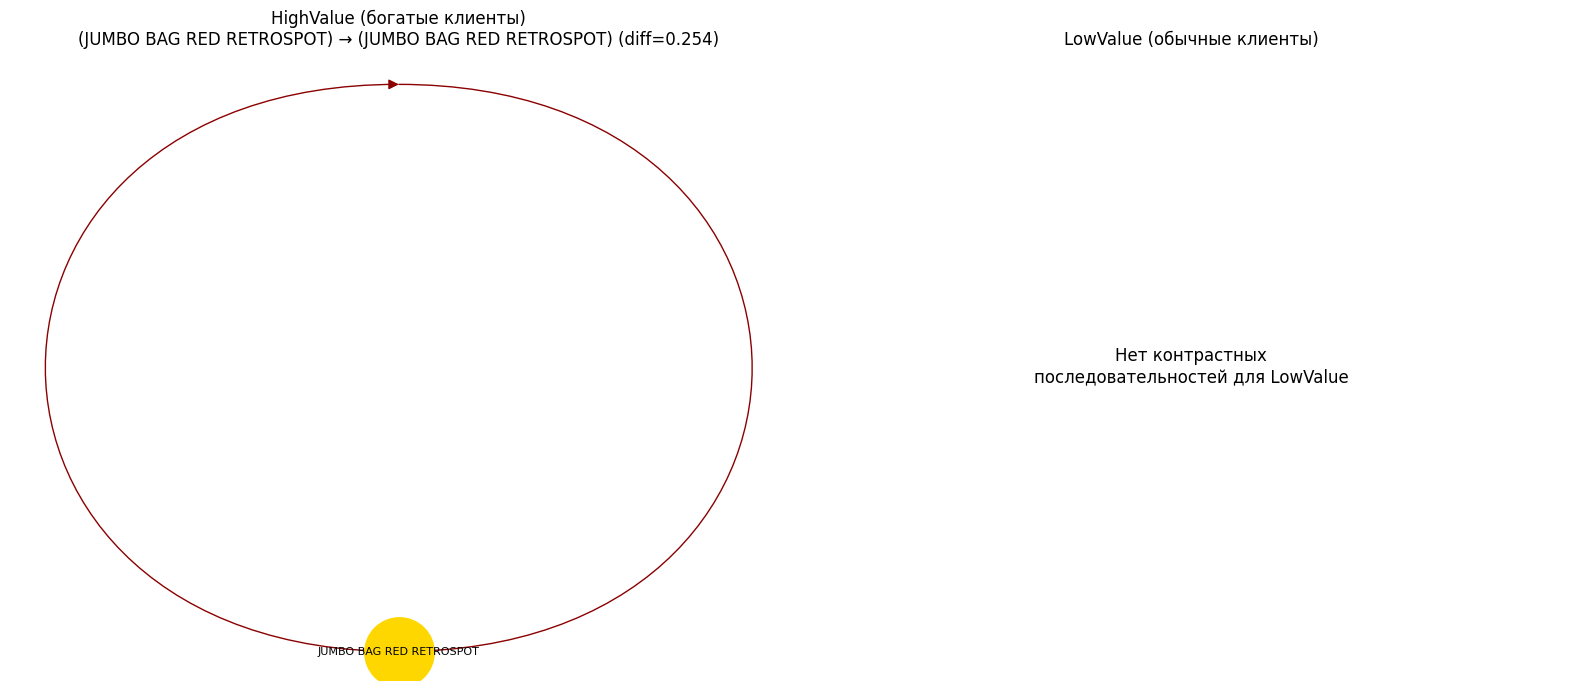

In [36]:
def seq_to_str(seq, max_items=2):
    items = []
    for it in seq:
        it_list = list(it)
        if len(it_list) > max_items:
            items.append("(" + ", ".join(it_list[:max_items]) + "...)")
        else:
            items.append("(" + ", ".join(it_list) + ")")
    return " → ".join(items)

revenue = df.groupby('CustomerID').apply(lambda g: (g['Quantity'] * g['Price']).sum())
q75 = revenue.quantile(0.75)
high_customers = set(revenue[revenue >= q75].index)
low_customers = set(revenue[revenue < q75].index)
print(f"HighValue клиентов: {len(high_customers)} (выручка ≥ {q75:.2f})")
print(f"LowValue клиентов: {len(low_customers)}")

def get_seqs(customers_set):
    df_cust = transactions[transactions['CustomerID'].isin(customers_set)]
    seqs = []
    for cust, group in df_cust.sort_values('InvoiceDate').groupby('CustomerID'):
        seq = group['itemset'].tolist()
        if len(seq) >= 2:
            seqs.append(seq)
    return seqs

high_seqs = get_seqs(high_customers)
low_seqs = get_seqs(low_customers)
print(f"HighValue последовательностей: {len(high_seqs)}")
print(f"LowValue последовательностей: {len(low_seqs)}")

freq_high = apriori_all(high_seqs, 0.05)
freq_low = apriori_all(low_seqs, 0.05)
print(f"HighValue частых: {len(freq_high)}")
print(f"LowValue частых: {len(freq_low)}")

contrast = {}
all_seqs = set(freq_high.keys()) | set(freq_low.keys())
for seq in all_seqs:
    sup_h = freq_high.get(seq, 0)
    sup_l = freq_low.get(seq, 0)
    contrast[seq] = sup_h - sup_l  

top2_high = sorted([(seq, diff) for seq, diff in contrast.items() if diff > 0], key=lambda x: -x[1])[:2]

top2_low = sorted([(seq, diff) for seq, diff in contrast.items() if diff < 0], key=lambda x: x[1])[:2]

print("\n Топ-2 последовательности у HighValue ")
for seq, diff in top2_high:
    sup_h = freq_high.get(seq, 0)
    sup_l = freq_low.get(seq, 0)
    print(f"  {seq_to_str(seq)} : diff={diff:.3f} (sup_h={sup_h:.3f}, sup_l={sup_l:.3f})")

print("\n Топ-2 последовательности у LowValue ")
for seq, diff in top2_low:
    sup_h = freq_high.get(seq, 0)
    sup_l = freq_low.get(seq, 0)
    print(f"  {seq_to_str(seq)} : diff={diff:.3f} (sup_h={sup_h:.3f}, sup_l={sup_l:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = ['gold', 'lightblue']
titles = ['HighValue (богатые клиенты)', 'LowValue (обычные клиенты)']

for idx, (seq_list, title, color) in enumerate(zip([top2_high, top2_low], titles, colors)):
    if not seq_list:
        axes[idx].text(0.5, 0.5, f"Нет контрастных\nпоследовательностей для {title.split()[0]}", 
                      ha='center', va='center', fontsize=12)
        axes[idx].set_title(title)
        axes[idx].axis('off')
        continue
    
    seq, diff = seq_list[0]
    G = nx.DiGraph()
    for i in range(len(seq) - 1):
        src = ", ".join(list(seq[i])[:3]) + ("..." if len(seq[i]) > 3 else "")
        dst = ", ".join(list(seq[i + 1])[:3]) + ("..." if len(seq[i + 1]) > 3 else "")
        G.add_edge(src, dst)
    
    pos = nx.spring_layout(G, seed=42, k=2)
    nx.draw(G, pos, ax=axes[idx], with_labels=True, node_color=color, 
            edge_color='darkred' if idx == 0 else 'darkblue',
            node_size=2500, font_size=8, arrows=True, arrowsize=15)
    axes[idx].set_title(f"{title}\n{seq_to_str(seq, max_items=2)} (diff={diff:.3f})")

plt.tight_layout()
plt.show()